# Instalacao de dependencias

In [1]:
import os, subprocess, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/rduarte12/information-retrieval-1.git"
REPO_DIR = "information-retrieval-1"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(os.path.join(REPO_DIR, "src"))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "../requirements.txt"], check=True)
    print(f"[Colab] repositorio clonado e dependencias instaladas. cwd = {os.getcwd()}")
else:
    print(f"[Local] cwd = {os.getcwd()} (esperado: .../information-retrieval-1/src)")

[Local] cwd = C:\Users\duart\directory\information-retrieval-1\src (esperado: .../information-retrieval-1/src)


In [2]:
import sys, os
sys.path.insert(0, os.getcwd())

from data_loader import load_cranfield

In [ ]:
# fazer load de modos de tokenização, stopwords, stemmers do nltk

# punkt e punkt_tab: servem para tokenização de sentenças e palavras
# stopwords: lista de stopwords
# stemmer: algoritmo de stemming

import nltk

for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.download(resource)
    except Exception as e:
        print(f"Erro ao baixar {resource}: {e}")



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\duart\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\duart\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\duart\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Carregar dataset

In [ ]:
# carregar dqtaset
docs, queries, qrels = load_cranfield()
print(f"Docs: {len(docs)}, Queries: {len(queries)}, Qrels: {len(qrels)}")

Docs: 1400, Queries: 225, Qrels: 1837


[INFO] Opening C:\Users\duart\.ir_datasets\cranfield/docs.pklz4\bin with direct file access


# Processar query e documentos

In [ ]:
from preprocessing import preprocess
import pickle, os

os.makedirs("results/corpora", exist_ok=True)

# dicionario para facilitar a ietracao sobre diferentes configureacoes de pre processamento

config_names = [
    "no_sw_no_stem",
    "sw_no_stem", 
    "no_sw_stem",
    "sw_stem"
]

configs = [
    {"remove_stopwords": False, "stem": False},
    {"remove_stopwords": True,  "stem": False},
    {"remove_stopwords": False, "stem": True},
    {"remove_stopwords": True,  "stem": True},
]

# fazer o pre processamento
for name, cfg in zip(config_names, configs):
    processed_docs    = {id: preprocess(t, **cfg) for id, t in docs.items()}
    processed_queries = {id: preprocess(t, **cfg) for id, t in queries.items()}
    
    with open(f"results/corpora/{name}_docs.pkl", "wb") as f:
        pickle.dump(processed_docs, f)
    with open(f"results/corpora/{name}_queries.pkl", "wb") as f:
        pickle.dump(processed_queries, f)

In [ ]:
import pandas as pd, os

# calcular estatisticas de pre processamento
rows = []
for cfg in configs:
    processed_docs = {id: preprocess(t, **cfg) for id, t in docs.items()}
    avg_len  = sum(len(t) for t in processed_docs.values()) / len(processed_docs)
    vocab    = set(tok for tokens in processed_docs.values() for tok in tokens)
    rows.append({"config": str(cfg), "avg_doc_len": avg_len, "vocab_size": len(vocab)})

os.makedirs("results/aggregated", exist_ok=True)
pd.DataFrame(rows).to_csv("results/aggregated/preprocessing_stats.csv", index=False)

# APlicar Modelo vetorial

## TF-IDF

O objetivo e transformar texto em vetores numericos para que possamos calcular similaridade matematicamente.

**TF (Term Frequency):** quantas vezes um termo aparece num documento.
- "flow" aparece 5 vezes no doc 42 => TF alto

**IDF (Inverse Document Frequency):** penaliza termos que aparecem em muitos documentos.
- "the" aparece em todos os docs => IDF baixo (nao e discriminativo)
- "aerodynamic" aparece em poucos docs => IDF alto (e discriminativo)

**TF-IDF = TF × IDF**
- Termo frequente no documento E raro no corpus => peso alto
- Termo frequente no documento MAS comum no corpus => peso baixo

O resultado e um vetor por documento, onde cada dimensao corresponde a um termo do vocabulario:

```
doc_42 = [0.0, 0.31, 0.0, 0.85, 0.0, 0.42, ...]
           the  flow  ...  aero  ...  drag
```

A maioria dos valores e zero (vetor esparso) um documento nao usa todos os termos do corpus.

## Similaridade do Cosseno

Dados dois vetores (query e documento), o cosseno mede o angulo entre eles:

```
score(q, d) = (q · d) / (||q|| × ||d||)
```

- Score = 1: vetores identicos (mesma direcao)
- Score = 0: vetores ortogonais (nenhum termo em comum)

## Ranqueamento

Para cada query:
1. A query tambem vira um vetor TF-IDF (no mesmo espaco dos documentos)
2. Calculamos o cosseno da query com cada documento do corpus
3. Ordenamos os documentos pelo score decrescente


## scikit-learn 

`TfidfVectorizer` faz automaticamente:
- Tokenizacao (substituido)
- Calculo de TF para cada documento
- Calculo de IDF sobre todo o corpus (com suavizacao para evitar divisao por zero)
- Normalizacao L2 dos vetores (deixa todos com comprimento 1, o que torna o produto escalar = cosseno)

`cosine_similarity(q, doc_matrix)` faz:
- Produto escalar da query contra todos os documentos de uma vez (operacao matricial eficiente)
- Retorna um array de scores, um por documento

In [ ]:
import pickle
from vector_model import VectorModel

config_names = ["no_sw_no_stem", "sw_no_stem", "no_sw_stem", "sw_stem"]

vector_models = {}
for name in config_names:
    with open(f"results/corpora/{name}_docs.pkl", "rb") as f:
        p_docs = pickle.load(f)
    with open(f"results/corpora/{name}_queries.pkl", "rb") as f:
        p_queries = pickle.load(f)

    vector_models[name] = VectorModel(p_docs, p_queries)

# teste para verificar se o ranking funciona (pegar ranking do doc 1)
ranking = vector_models["sw_stem"].rank("1")
print(ranking[:5])

[('51', np.float64(0.31546628631602747)), ('359', np.float64(0.21328303370290472)), ('746', np.float64(0.19879438742240085)), ('12', np.float64(0.19237099799937524)), ('486', np.float64(0.18262692173543646))]


In [ ]:
# slava os rankings para cada modelo 

for name in config_names:
    rankings = {q_id: vector_models[name].rank(q_id) for q_id in p_queries.keys()}
    try:
        os.makedirs("results/rankings", exist_ok=True)
        
    except Exception as e:
        Exception(f"Erro ao criar diretorio results/rankings: {e}")


    try:    
        with open(f"results/rankings/vector_{name}.pkl", "wb") as f:
            pickle.dump(rankings, f)

    except Exception as e:
        Exception(f"Erro ao salvar rankings para {name}: {e}")

In [ ]:
# teste de busca com frase no con texto da base
ranking = vector_models["sw_stem"].search("aerodynamic flow over wings", remove_stopwords=True, stem=True)

In [10]:
for rank, (doc_id, score) in enumerate(ranking[:5], 1):
    print(f"\n--- Rank {rank} | doc_id={doc_id} | score={score:.4f} ---")
    print(docs[doc_id][:500])


--- Rank 1 | doc_id=52 | score=0.3375 ---
procedure for calculating flutter at high supersonic
speed including camber deflections, and comparison
with experimental results .
  a method which may be used at high supersonic mach numbers is
described for calculating the flutter speed of wings having camber in
their deflection modes .  the normal coupled vibration modes of the wing
are used to derive the equations of motion .  chord deflections of the
vibration modes are approximated by polynomials .  the wing may have a
control surface and

--- Rank 2 | doc_id=749 | score=0.3280 ---
the aerodynamic effects of aspect ratio and sweepback
on wing flutter .
  the report describes tests to obtain direct
measurements of the aerodynamic effects of aspect ratio and
sweepback on wing flutter .  the tests were made on rigid
wings with root flexibilities .
  it is shown that measured effects of aspect ratio and
sweepback on the flutter of these wings can be represented
quite closely in flutter calc

# BM25

In [11]:
from bm25 import BM25

bm25_models = {}
for name in config_names:
    with open(f"results/corpora/{name}_docs.pkl", "rb") as f:
        p_docs = pickle.load(f)
    with open(f"results/corpora/{name}_queries.pkl", "rb") as f:
        p_queries = pickle.load(f)

    bm25_models[name] = BM25(p_docs, p_queries)

# salva rankings das 4 configs
for name in config_names:
    rankings = {q_id: bm25_models[name].rank(q_id) for q_id in p_queries.keys()}
    with open(f"results/rankings/bm25_{name}.pkl", "wb") as f:
        pickle.dump(rankings, f)

In [12]:
# corpus artificial para teste
fake_docs = {
    "d1": ["flow"] * 1,
    "d2": ["flow"] * 10,
    "d3": ["flow"] * 100
}
fake_queries = {"q1": ["flow"]}

m = BM25(fake_docs, fake_queries)

for doc_id, score in m.rank("q1"):
    print(f"{doc_id} (freq={fake_docs[doc_id].count('flow'):3d}): score={score:.4f}")

d3 (freq=100): score=0.2860
d2 (freq= 10): score=0.2786
d1 (freq=  1): score=0.2218


In [13]:
import os, pickle, pandas as pd
from evaluation import evaluate, aggregate

os.makedirs("results/per_query",   exist_ok=True)
os.makedirs("results/aggregated",  exist_ok=True)

config_names = ["no_sw_no_stem", "sw_no_stem", "no_sw_stem", "sw_stem"]
model_names  = ["vector", "bm25"]

summary_rows = []

for model in model_names:
    for cfg in config_names:
        with open(f"results/rankings/{model}_{cfg}.pkl", "rb") as f:
            rankings = pickle.load(f)

        df  = evaluate(rankings, qrels)
        agg = aggregate(df)

        # salva por query
        df.to_csv(f"results/per_query/{model}_{cfg}.csv", index=False)

        # acumula agregado
        summary_rows.append({"model": model, "config": cfg, **agg})

# salva agregado
pd.DataFrame(summary_rows).to_csv("results/aggregated/metrics_summary.csv", index=False)

# Tabelas e Gráficos para Analsies

In [14]:
import matplotlib.pyplot as plt

summary = pd.read_csv("results/aggregated/metrics_summary.csv")
config_names = ["no_sw_no_stem", "sw_no_stem", "no_sw_stem", "sw_stem"]
metricas = ["MAP", "MRR", "P@10", "R@10", "F1@10", "NDCG@10"]

In [15]:
tabela = summary[["model", "config"] + metricas].sort_values(["config", "model"])
tabela.to_csv("results/aggregated/model_comparison.csv", index=False)
print(tabela.to_string(index=False))

 model        config      MAP      MRR     P@10     R@10    F1@10  NDCG@10
  bm25 no_sw_no_stem 0.250539 0.486459 0.206222 0.339403 0.232355 0.289712
vector no_sw_no_stem 0.244980 0.485942 0.199556 0.319828 0.223041 0.282867
  bm25    no_sw_stem 0.274804 0.512441 0.215556 0.366170 0.245168 0.313226
vector    no_sw_stem 0.264605 0.503333 0.216889 0.364818 0.245418 0.307161
  bm25    sw_no_stem 0.260946 0.492618 0.217778 0.356912 0.245284 0.302508
vector    sw_no_stem 0.249461 0.482373 0.209333 0.338293 0.233909 0.291948
  bm25       sw_stem 0.288489 0.524929 0.221333 0.369660 0.250693 0.322159
vector       sw_stem 0.273446 0.513328 0.220444 0.368243 0.248963 0.313027


C:\Users\duart\AppData\Local\Temp\ipykernel_26124\1005121951.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(config_names, rotation=15, ha="right")
C:\Users\duart\AppData\Local\Temp\ipykernel_26124\1005121951.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(config_names, rotation=15, ha="right")
C:\Users\duart\AppData\Local\Temp\ipykernel_26124\1005121951.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(config_names, rotation=15, ha="right")
C:\Users\duart\AppData\Local\Temp\ipykernel_26124\1005121951.py:12: UserWarning: set_ticklabels() should only be used with a

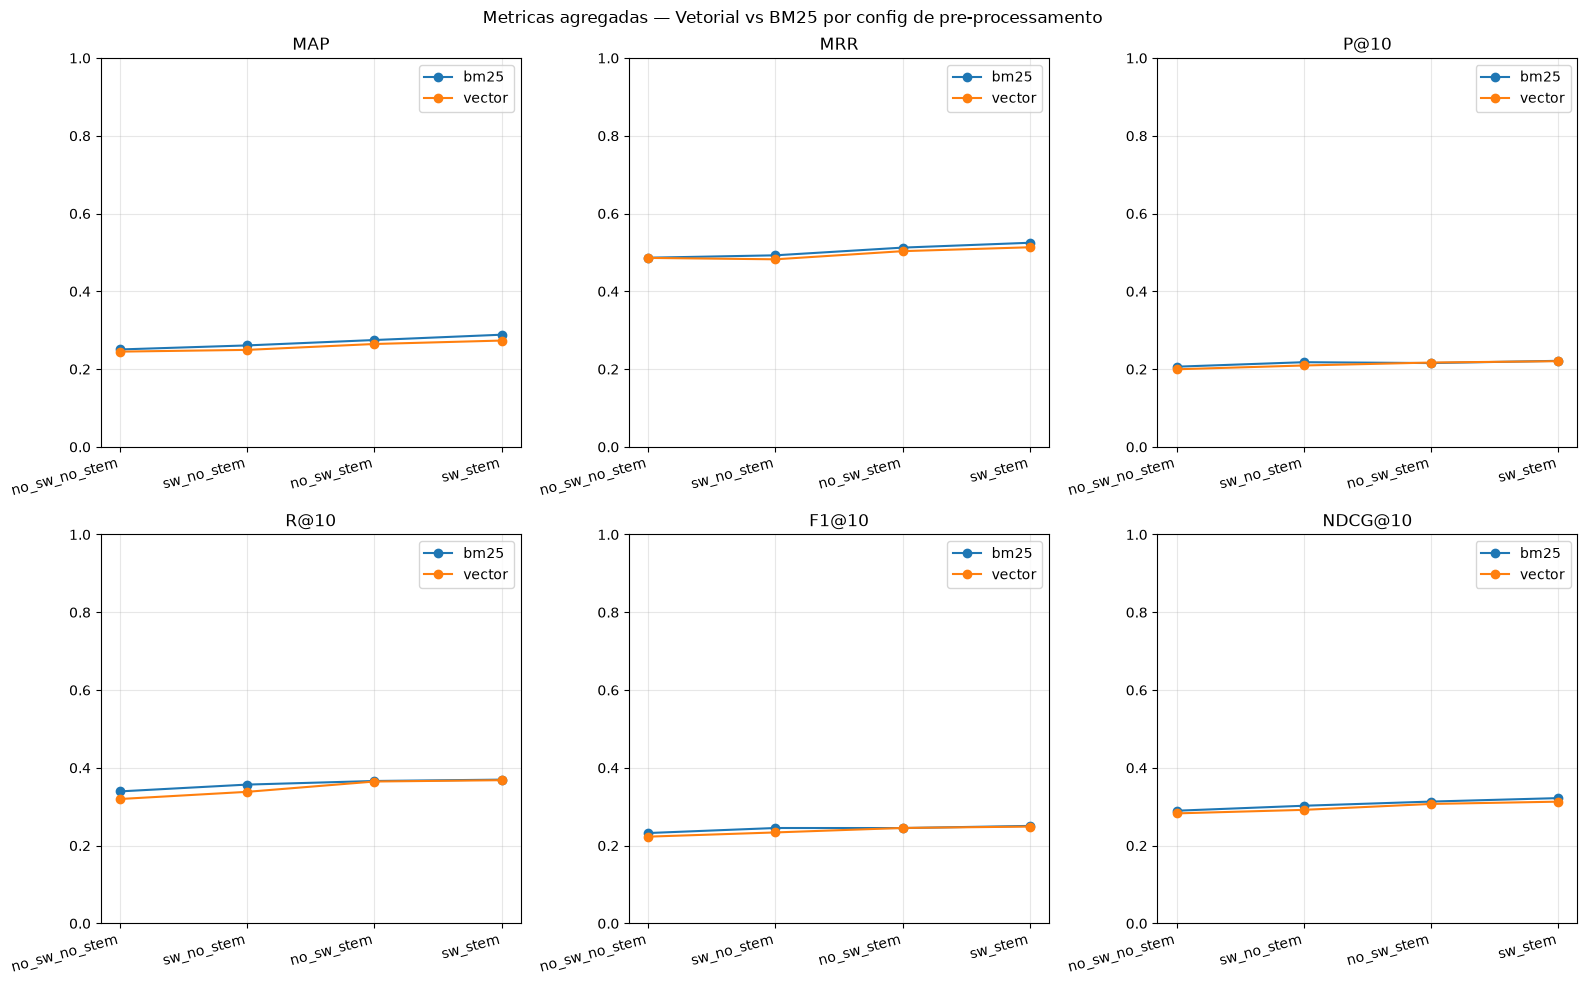

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metricas):
    ax = axes[i]
    for model, group in summary.groupby("model"):
        ax.plot(config_names, 
                [group[group["config"] == c][metrica].values[0] for c in config_names],
                marker="o", label=model)
    ax.set_title(metrica)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Metricas agregadas: Vetorial vs BM25 por config de pre-processamento")
plt.tight_layout()
plt.savefig("results/aggregated/metrics_by_config.png", dpi=150)
plt.show()

In [ ]:
# monta df_all/vec/bm25 a partir dos CSVs por-query ja salvos
vec  = pd.read_csv("results/per_query/vector_sw_stem.csv")
bm25 = pd.read_csv("results/per_query/bm25_sw_stem.csv")

vec_labeled  = vec.assign(model="Vetorial")
bm25_labeled = bm25.assign(model="BM25")
df_all = pd.concat([vec_labeled, bm25_labeled], ignore_index=True)


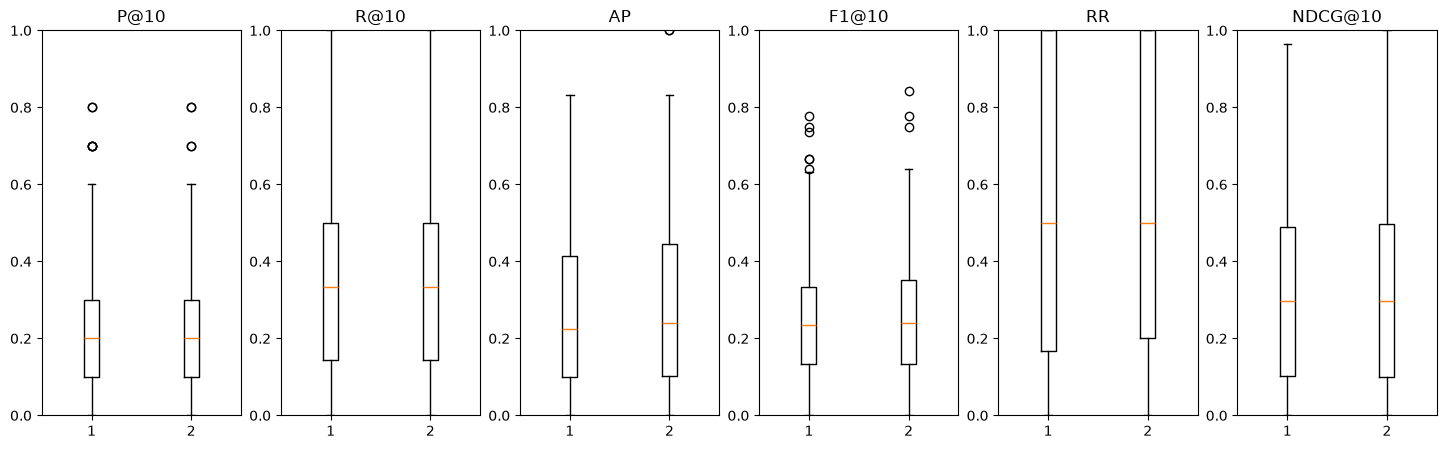

In [ ]:
# metricas corretas para os CSVs per_query
metricas_per_query = ["P@10", "R@10", "AP", "F1@10", "RR", "NDCG@10"]

fig, axes = plt.subplots(1, len(metricas_per_query), figsize=(18, 5))
for ax, metrica in zip(axes, metricas_per_query):
    data = [
        df_all[df_all["model"] == "Vetorial"][metrica],
        df_all[df_all["model"] == "BM25"][metrica]
    ]
    ax.boxplot(data, label=["Vetorial", "BM25"])
    ax.set_title(metrica)
    ax.set_xticklabels(["Vetorial", "BM25"])
    ax.set_ylim(0, 1)

In [19]:
merged = vec[["query_id", "AP"]].merge(
    bm25[["query_id", "AP"]], on="query_id", suffixes=("_vec", "_bm25")
)
merged["diff"] = merged["AP_bm25"] - merged["AP_vec"]
merged = merged.sort_values("diff")
merged.to_csv("results/aggregated/per_query_diff.csv", index=False)

print("=== Top-5 Vetorial superior ===")
print(merged.head(5).to_string(index=False))

print("\n=== Top-5 BM25 superior ===")
print(merged.tail(5).to_string(index=False))

=== Top-5 Vetorial superior ===
 query_id   AP_vec  AP_bm25      diff
      145 0.589940 0.161608 -0.428332
       77 0.544775 0.185582 -0.359193
      178 0.475490 0.182697 -0.292793
      191 0.632305 0.361208 -0.271097
      144 0.668849 0.413533 -0.255316

=== Top-5 BM25 superior ===
 query_id   AP_vec  AP_bm25     diff
       36 0.168850 0.502849 0.333999
      205 0.350000 0.700000 0.350000
      173 0.583333 1.000000 0.416667
       81 0.267857 0.833333 0.565476
      167 0.107955 0.750000 0.642045


# Análise por consulta (Requisito 6)

Critério de seleção das 6 consultas, a partir de `results/aggregated/per_query_diff.csv` (config `sw_stem`, AP por consulta) e `results/per_query/{model}_sw_stem.csv`:

- **BM25 superior ao Vetorial**: as 2 consultas com maior `diff = AP_bm25 - AP_vec` positivo => queries **167** e **81**.
- **Vetorial superior ao BM25**: as 2 consultas com `diff` mais negativo => queries **145** e **77**.
- **Ambos insatisfatórios**: as 2 consultas com menor `max(AP_vec, AP_bm25)` entre todas as 225 (ambos os modelos falham, não apenas um) => queries **31** e **22**.

Para cada consulta, mostramos o Top-5 de cada modelo, indicando quais documentos são relevantes (qrels binarizados, grau ≥ 1).

In [20]:
import pickle
import pandas as pd
from evaluation import binarize_qrels

with open("results/rankings/vector_sw_stem.pkl", "rb") as f:
    vector_rankings = pickle.load(f)
with open("results/rankings/bm25_sw_stem.pkl", "rb") as f:
    bm25_rankings = pickle.load(f)

relevant_bin = binarize_qrels(qrels)

case_queries = {
    "BM25 >> Vetorial":        ["167", "81"],
    "Vetorial >> BM25":        ["145", "77"],
    "Ambos insatisfatorios":   ["31", "22"],
}

rows = []
for case, qids in case_queries.items():
    for qid in qids:
        relevant = relevant_bin.get(qid, set())
        for model_name, rankings in [("Vetorial", vector_rankings), ("BM25", bm25_rankings)]:
            top5 = rankings[qid][:5]
            for rank, (doc_id, score) in enumerate(top5, 1):
                rows.append({
                    "caso":         case,
                    "query_id":     qid,
                    "query_text":   queries[qid].strip().replace("\n", " "),
                    "n_relevantes": len(relevant),
                    "modelo":       model_name,
                    "rank":         rank,
                    "doc_id":       doc_id,
                    "score":        score,
                    "relevante":    doc_id in relevant,
                    "doc_snippet":  docs[doc_id][:150].strip().replace("\n", " "),
                })

query_case_studies = pd.DataFrame(rows)
query_case_studies.to_csv("results/aggregated/query_case_studies.csv", index=False)

pd.set_option("display.max_colwidth", 60)
query_case_studies

,caso,query_id,query_text,n_relevantes,modelo,rank,doc_id,score,relevante,doc_snippet
0,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,1,553,0.368314,False,ablation of glassy materials around blunt bodies of revo...
1,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,2,1099,0.293576,False,a theoretical study of stagnation point ablation . a sim...
2,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,3,1279,0.292589,False,sublimation in a hypersonic environment . a priori kno...
3,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,4,1097,0.273580,False,experimental ablation cooling . this paper presents th...
4,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,Vetorial,5,1100,0.258729,False,an analytical investigation of ablation . an analytical ...
5,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,1,274,23.808362,True,analysis of quartz and teflon shields for a particular r...
6,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,2,553,23.307737,False,ablation of glassy materials around blunt bodies of revo...
7,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,3,1279,22.930036,False,sublimation in a hypersonic environment . a priori kno...
8,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,4,82,20.902792,True,theoretical investigation of the ablation of a glass-typ...
9,BM25 >> Vetorial,167,exact solution methods for calculating the ablative mass...,2,BM25,5,1100,15.275672,False,an analytical investigation of ablation . an analytical ...


In [21]:
# Evidencia de apoio para a analise: tamanho dos documentos (em tokens, config sw_stem)
# citados no Top-5 de cada caso, e posicao real do doc relevante nas consultas "ambos insatisfatorios"
# (nao aparece no Top-5 de nenhum dos dois modelos)

with open("results/corpora/sw_stem_docs.pkl", "rb") as f:
    sw_stem_docs = pickle.load(f)

print("=== Tamanho dos documentos citados (BM25 >> Vetorial e Vetorial >> BM25) ===")
doc_pairs = {
    "167 (BM25>>Vet)": [("274", "relevante, rank1 BM25"), ("553", "NAO relevante, rank1 Vetorial")],
    "81  (BM25>>Vet)": [("799", "relevante, rank1 BM25"), ("714", "NAO relevante, rank1 Vetorial")],
    "145 (Vet>>BM25)": [("1045", "relevante, rank1 Vetorial"), ("1126", "NAO relevante, rank1 BM25")],
    "77  (Vet>>BM25)": [("667", "relevante, rank1 Vetorial"), ("1264", "NAO relevante, rank1 BM25")],
}
for qid, pairs in doc_pairs.items():
    for doc_id, label in pairs:
        print(f"  query {qid} | doc {doc_id:>5} | {len(sw_stem_docs[doc_id]):3d} tokens | {label}")

print("\n=== Consultas 'ambos insatisfatorios': onde o doc relevante realmente aparece ===")
for qid in ["31", "22"]:
    doc_id = next(iter(relevant_bin[qid]))
    v_pos = [d for d, _ in vector_rankings[qid]].index(doc_id) + 1
    b_pos = [d for d, _ in bm25_rankings[qid]].index(doc_id) + 1
    print(f"\nquery {qid}: \"{queries[qid].strip()}\"")
    print(f"  doc relevante = {doc_id} | rank no Vetorial: {v_pos}/1400 | rank no BM25: {b_pos}/1400")
    print(f"  texto do doc : {docs[doc_id][:200].strip()}")

=== Tamanho dos documentos citados (BM25 >> Vetorial e Vetorial >> BM25) ===
  query 167 (BM25>>Vet) | doc   274 | 160 tokens | relevante, rank1 BM25
  query 167 (BM25>>Vet) | doc   553 | 104 tokens | NAO relevante, rank1 Vetorial
  query 81  (BM25>>Vet) | doc   799 | 151 tokens | relevante, rank1 BM25
  query 81  (BM25>>Vet) | doc   714 |  67 tokens | NAO relevante, rank1 Vetorial
  query 145 (Vet>>BM25) | doc  1045 |  18 tokens | relevante, rank1 Vetorial
  query 145 (Vet>>BM25) | doc  1126 |  62 tokens | NAO relevante, rank1 BM25
  query 77  (Vet>>BM25) | doc   667 | 153 tokens | relevante, rank1 Vetorial
  query 77  (Vet>>BM25) | doc  1264 | 141 tokens | NAO relevante, rank1 BM25

=== Consultas 'ambos insatisfatorios': onde o doc relevante realmente aparece ===

query 31: "what size of end plate can be safely used to simulate two-dimensional
flow conditions over a bluff cylindrical body of finite aspect ratio ."
  doc relevante = 776 | rank no Vetorial: 1350/1400 | rank no BM25: 13

## Rascunho de anotações (para reaproveitar no relatório)

**BM25 claramente superior ao Vetorial (queries 167 e 81):** em ambos os casos o documento
relevante é relativamente longo (160 e 151 tokens) e contém o termo mais discriminativo da
consulta (ex.: "ablat*" na query 167, "tunnel"/"interference" na 81) com frequência moderada.
No modelo vetorial ele fica fora do Top-5 (ou em rank baixo), enquanto documentos mais curtos
(104 e 67 tokens) sobem ao topo por pura similaridade de cosseno. Hipótese: a normalização L2
do cosseno divide pelo módulo do vetor do documento inteiro — um documento curto concentra seu
peso TF-IDF em poucos termos, o que infla artificialmente sua similaridade com a query mesmo
sem ser o mais relevante. O BM25, por não normalizar dessa forma (usa apenas o fator
`1 - b + b·|D|/avgdl` no denominador, calibrado por `b`), consegue premiar o termo raro/discriminativo
no documento correto mesmo ele sendo mais longo que a média.

**Vetorial claramente superior ao BM25 (queries 145 e 77):** aqui o padrão se inverte: o
documento relevante da query 145 é mais curto (18 tokens) e tem match exato com 3 dos
termos da consulta ("bend", "pressur", "cylind"); o cosseno o classifica em 1º lugar, mas o
BM25 o deixa em 4º, atrás de um documento 3,4x mais longo (62 tokens) e não relevante. Query 145
é uma consulta com muitos termos de conteúdo ("best experimental data classical small deflection
theory analyses pressurized cylinders bending"); hipótese: como o score do BM25 é uma soma
independente por termo, documentos mais longos têm mais chance estatística de conter *algum*
match para cada um dos vários termos da query (ainda que fracos), acumulando pontuação agregada
maior: mesmo sem reproduzir com precisão o foco temático da query. O cosseno, ao normalizar
pelo vetor do documento inteiro, recompensa a alta concentração temática do documento curto.

**Ambos insatisfatórios (queries 31 e 22):** nos dois casos o único documento relevante fica
enterrado na segunda metade do ranking em ambos os modelos (doc 776: rank 1350/1400 no Vetorial,
1375/1400 no BM25; doc 68: rank 989/1400 no Vetorial, 1042/1400 no BM25). Inspecionando os
textos, não há sobreposição lexical relevante entre a consulta e o documento, ex.: a query 31
pergunta sobre "end plate"/"aspect ratio" para simular escoamento bidimensional, e o documento
relevante fala em "cilindros quadrados e dodecagonais" sem citar esses termos. Hipótese: é um
caso clássico de mismatch de vocabulário (sinonímia/generalização) que nenhum modelo puramente
lexical (TF-IDF ou BM25) consegue resolver, pois ambos dependem de sobreposição exata de termos: a relação entre consulta e documento é conceitual/semântica, não lexical.

# Variação de parâmetros do BM25 (Requisito 7)

Grid completo `k1 ∈ {0.5, 1.2, 2.0} × b ∈ {0, 0.75, 1}` (9 combinações), usando o BM25 já construído
para a config padrão (`sw_stem`). Como `k1`/`b` são apenas atributos usados em tempo de score
(não afetam `tf`, `df`, `doc_lens` ou `avgdl`, pré-calculados no `__init__`), reaproveitamos a
mesma instância `bm25_models["sw_stem"]` e só reatribuímos `k1`/`b` a cada combinação, sem
reconstruir o índice.

In [22]:
import itertools

k1_values = [0.5, 1.2, 2.0]
b_values  = [0, 0.75, 1]

bm25_sw_stem = bm25_models["sw_stem"]

grid_rows = []
for k1, b in itertools.product(k1_values, b_values):
    bm25_sw_stem.k1 = k1
    bm25_sw_stem.b  = b
    rankings = {qid: bm25_sw_stem.rank(qid) for qid in bm25_sw_stem.query_ids}
    df  = evaluate(rankings, qrels)
    agg = aggregate(df)
    grid_rows.append({"k1": k1, "b": b, "MAP": agg["MAP"], "NDCG@10": agg["NDCG@10"]})

# restaura os parametros padrao usados no resto do notebook
bm25_sw_stem.k1, bm25_sw_stem.b = 1.2, 0.75

bm25_param_grid = pd.DataFrame(grid_rows)
os.makedirs("results/aggregated", exist_ok=True)
bm25_param_grid.to_csv("results/aggregated/bm25_param_grid.csv", index=False)
print(bm25_param_grid.to_string(index=False))

 k1    b      MAP  NDCG@10
0.5 0.00 0.258785 0.289492
0.5 0.75 0.277033 0.311227
0.5 1.00 0.276188 0.310645
1.2 0.00 0.266390 0.299719
1.2 0.75 0.288489 0.322159
1.2 1.00 0.289460 0.323967
2.0 0.00 0.268176 0.300670
2.0 0.75 0.292517 0.328069
2.0 1.00 0.290898 0.327592


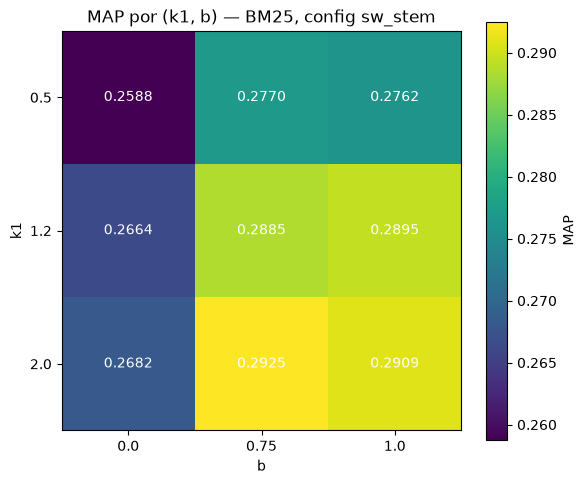

In [23]:
pivot_map = bm25_param_grid.pivot(index="k1", columns="b", values="MAP")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot_map.values, cmap="viridis")
ax.set_xticks(range(len(pivot_map.columns))); ax.set_xticklabels(pivot_map.columns)
ax.set_yticks(range(len(pivot_map.index)));   ax.set_yticklabels(pivot_map.index)
ax.set_xlabel("b")
ax.set_ylabel("k1")
ax.set_title("MAP por (k1, b) — BM25, config sw_stem")
for i in range(len(pivot_map.index)):
    for j in range(len(pivot_map.columns)):
        ax.text(j, i, f"{pivot_map.values[i, j]:.4f}", ha="center", va="center", color="white")
plt.colorbar(im, ax=ax, label="MAP")
plt.tight_layout()
plt.savefig("results/aggregated/bm25_param_heatmap.png", dpi=150)
plt.show()

## Consulta onde `b` muda perceptivelmente o Top-10 (k1 fixo em 1.2)

Calculamos o Top-10 de todas as 225 consultas para `b=0` (sem normalização por tamanho do
documento) e `b=1` (normalização máxima), com `k1=1.2` fixo, e escolhemos a consulta cujo
Top-10 mais mudou (maior diferença simétrica de conjuntos) entre os dois extremos.

In [24]:
bm25_sw_stem.k1 = 1.2

bm25_sw_stem.b = 0.0
top10_b0 = {qid: [d for d, _ in bm25_sw_stem.rank(qid)[:10]] for qid in bm25_sw_stem.query_ids}

bm25_sw_stem.b = 1.0
top10_b1 = {qid: [d for d, _ in bm25_sw_stem.rank(qid)[:10]] for qid in bm25_sw_stem.query_ids}

# restaura o parametro padrao
bm25_sw_stem.b = 0.75

diffs = {qid: len(set(top10_b0[qid]) ^ set(top10_b1[qid])) for qid in bm25_sw_stem.query_ids}
best_qid = max(diffs, key=diffs.get)
print(f"Consulta escolhida: {best_qid} (diferenca simetrica de {diffs[best_qid]} documentos no Top-10)")
print(f"Texto: {queries[best_qid].strip()}")

relevant = relevant_bin.get(best_qid, set())

comparison_rows = []
for rank, doc_id in enumerate(top10_b0[best_qid], 1):
    comparison_rows.append({"rank": rank, "b=0 doc_id": doc_id, "relevante (b=0)": doc_id in relevant})
for rank, doc_id in enumerate(top10_b1[best_qid], 1):
    comparison_rows[rank - 1]["b=1 doc_id"] = doc_id
    comparison_rows[rank - 1]["relevante (b=1)"] = doc_id in relevant

b_comparison = pd.DataFrame(comparison_rows)
b_comparison.to_csv("results/aggregated/bm25_b_param_query_comparison.csv", index=False)
b_comparison

Consulta escolhida: 124 (diferenca simetrica de 16 documentos no Top-10)
Texto: in what areas, other than low density wind tunnel flows, is viscous
compressible flow in slender channels a problem .
what analytical investigations have been made of the stability of
conical shells . how do the results compare with experiment .


,rank,b=0 doc_id,relevante (b=0),b=1 doc_id,relevante (b=1)
0,1,941,False,941,False
1,2,792,False,898,False
2,3,25,False,516,False
3,4,625,False,514,False
4,5,1313,False,938,False
5,6,442,False,1288,False
6,7,9,False,442,False
7,8,1274,False,1070,False
8,9,656,False,934,False
9,10,1319,False,183,False


## Rascunho de discussão do efeito de k1 e b (para o relatório)

**Efeito de `b` (normalização por tamanho do documento):** para qualquer `k1`, `b=0` é
claramente pior que `b=0.75` ou `b=1` (ex.: `k1=1.2` → MAP 0.2664 em `b=0` contra 0.2885 em
`b=0.75`, uma queda de ~8%). Isso mostra que a coleção Cranfield tem variação de tamanho de
documento suficiente para que ignorar essa normalização prejudique o ranking — documentos mais
longos acumulam frequência de termos só por serem longos, não por serem mais relevantes.
`b=0.75` e `b=1` ficam próximos entre si (diferença de MAP < 0.002 em todos os `k1`), com uma
leve vantagem para `b=1` em `k1=1.2` e leve vantagem para `b=0.75` em `k1=2.0` — ou seja, nesta
coleção a normalização completa (`b=1`) não piora o resultado em relação ao valor "de
livro-texto" (`b=0.75`).

**Efeito de `k1` (saturação de frequência de termo):** fixando `b`, aumentar `k1` de 0.5 para
2.0 melhora o MAP de forma consistente (ex.: em `b=0.75`: 0.2770 → 0.2885 → 0.2925). Como
Cranfield tem resumos curtos e técnicos, onde a repetição de um termo tende a ser um sinal
genuíno de foco temático (e não "spam"), um `k1` mais alto — que deixa a frequência do termo
contribuir por mais tempo antes de saturar — ajuda ligeiramente. A melhor combinação do grid é
`k1=2.0, b=0.75` (MAP=0.2925, NDCG@10=0.3281); a pior é `k1=0.5, b=0` (MAP=0.2588).

**Consulta 124** ("...viscous compressible flow in slender channels...stability of conical
shells...") foi a que teve o Top-10 mais alterado por `b` (apenas 2 documentos em comum entre
`b=0` e `b=1`, de 10). Os documentos do Top-10 com `b=0` têm em média 201.6 tokens — quase o
dobro do tamanho médio do corpus (`avgdl≈104.4`) — enquanto com `b=1` a média cai para 78.0
tokens, abaixo da média do corpus. É exatamente o comportamento esperado da fórmula: sem
normalização, documentos longos vencem por acumular mais ocorrências brutas dos termos da
query; com normalização plena, documentos mais curtos que a média passam a ser favorecidos
porque sua frequência relativa de termo é mais alta. Nenhuma das duas variantes traz os 4
documentos relevantes desta consulta para o Top-10 — um bom candidato adicional para a análise
de erros da Sprint 9.

# Sprint 8 — Modificação de consultas (Requisito 8)

5 consultas originais do Cranfield, cada uma com uma versão modificada manualmente (estratégias:
remoção/acréscimo de termos, sinônimos, mais específica ou mais genérica). As modificações foram
pensadas de forma independente dos qrels — não usamos os julgamentos de relevância para "colar"
vocabulário do documento relevante na query, o que violaria a regra de não usar os qrels para
ajustar o ranking.

| # | query_id | Estratégia | Original → Modificada |
|---|---|---|---|
| 1 | 31  | Generalização (remove qualificador) | "...bluff **cylindrical** body..." → "...bluff body..." |
| 2 | 167 | Remoção de termos (compressão) | "exact solution methods for calculating the ablative mass loss..." → "the ablative mass loss..." |
| 3 | 145 | Sinônimo ("cylinders"→"shells") | "...pressurized **cylinders** in bending." → "...pressurized **shells** in bending." |
| 4 | 100 | Mais específica (acréscimo de qualificadores) | "...effects of **initial imperfections**... **cylindrical shells**..." → "...effects of **small initial geometric imperfections**... **thin** cylindrical shells..." |
| 5 | 50  | Remoção de termos + generalização | "...effects of **small amounts of** gas rarefaction...**slender** bodies of revolution." → "...effects of gas rarefaction...bodies of revolution." |

Rodamos original vs. modificada nos modelos Vetorial e BM25 (config padrão `sw_stem`), comparando o Top-10.

In [25]:
query_pairs = [
    {
        "query_id":   "31",
        "estrategia": "Generalizacao (remove qualificador)",
        "modificada": "what size of end plate can be safely used to simulate two-dimensional flow conditions over a bluff body of finite aspect ratio .",
    },
    {
        "query_id":   "167",
        "estrategia": "Remocao de termos (compressao)",
        "modificada": "the ablative mass loss of a material ablating at high temperatures .",
    },
    {
        "query_id":   "145",
        "estrategia": "Sinonimo (cylinders -> shells)",
        "modificada": "what are the best experimental data and classical small deflection theory analyses available for pressurized shells in bending .",
    },
    {
        "query_id":   "100",
        "estrategia": "Mais especifica (acrescimo de qualificadores)",
        "modificada": "what are the effects of small initial geometric imperfections on the elastic buckling of thin cylindrical shells under axial compression .",
    },
    {
        "query_id":   "50",
        "estrategia": "Remocao de termos + generalizacao",
        "modificada": "what are the effects of gas rarefaction on the characteristics of the boundary layers on bodies of revolution .",
    },
]

vector_sw_stem = vector_models["sw_stem"]

reformulation_rows = []
for pair in query_pairs:
    qid = pair["query_id"]
    original_text = queries[qid].strip().replace("\n", " ")
    modified_text = pair["modificada"]
    relevant      = relevant_bin.get(qid, set())

    for versao, text in [("original", original_text), ("modificada", modified_text)]:
        vec_top10  = vector_sw_stem.search(text, remove_stopwords=True, stem=True)[:10]
        bm25_top10 = bm25_sw_stem.search(text, remove_stopwords=True, stem=True)[:10]

        for modelo, top10 in [("Vetorial", vec_top10), ("BM25", bm25_top10)]:
            for rank, (doc_id, score) in enumerate(top10, 1):
                reformulation_rows.append({
                    "query_id":    qid,
                    "estrategia":  pair["estrategia"],
                    "versao":      versao,
                    "query_text":  text,
                    "modelo":      modelo,
                    "rank":        rank,
                    "doc_id":      doc_id,
                    "score":       score,
                    "relevante_para_query_original": doc_id in relevant,
                })

query_reformulation = pd.DataFrame(reformulation_rows)
query_reformulation.to_csv("results/aggregated/query_reformulation.csv", index=False)
query_reformulation

,query_id,estrategia,versao,query_text,modelo,rank,doc_id,score,relevante_para_query_original
0,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,1,751,0.374748,False
1,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,2,68,0.188009,False
2,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,3,918,0.171308,False
3,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,4,247,0.165531,False
4,31,Generalizacao (remove qualificador),original,what size of end plate can be safely used to simulate tw...,Vetorial,5,916,0.155540,False
...,...,...,...,...,...,...,...,...,...
195,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,6,1263,11.730153,False
196,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,7,192,11.317325,False
197,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,8,353,11.294747,False
198,50,Remocao de termos + generalizacao,modificada,what are the effects of gas rarefaction on the character...,BM25,9,421,11.156272,False


In [26]:
# resumo: quantos documentos do Top-10 permanecem iguais entre original e modificada
summary_rows = []
for pair in query_pairs:
    qid = pair["query_id"]
    for modelo in ["Vetorial", "BM25"]:
        orig_docs = query_reformulation.query("query_id == @qid and versao == 'original' and modelo == @modelo")["doc_id"].tolist()
        mod_docs  = query_reformulation.query("query_id == @qid and versao == 'modificada' and modelo == @modelo")["doc_id"].tolist()
        overlap = len(set(orig_docs) & set(mod_docs))
        summary_rows.append({
            "query_id":              qid,
            "estrategia":            pair["estrategia"],
            "modelo":                modelo,
            "docs_em_comum_top10":   overlap,
            "docs_diferentes_top10": 10 - overlap,
        })

reformulation_summary = pd.DataFrame(summary_rows)
reformulation_summary.to_csv("results/aggregated/query_reformulation_summary.csv", index=False)
print(reformulation_summary.to_string(index=False))

query_id                                    estrategia   modelo  docs_em_comum_top10  docs_diferentes_top10
      31           Generalizacao (remove qualificador) Vetorial                    9                      1
      31           Generalizacao (remove qualificador)     BM25                    8                      2
     167                Remocao de termos (compressao) Vetorial                    8                      2
     167                Remocao de termos (compressao)     BM25                    7                      3
     145                Sinonimo (cylinders -> shells) Vetorial                    3                      7
     145                Sinonimo (cylinders -> shells)     BM25                    5                      5
     100 Mais especifica (acrescimo de qualificadores) Vetorial                    9                      1
     100 Mais especifica (acrescimo de qualificadores)     BM25                    8                      2
      50             Remocao

In [27]:
# quantos dos documentos relevantes (para a query ORIGINAL) continuam no Top-10 apos a modificacao
relevantes_no_top10 = (
    query_reformulation
    .groupby(["query_id", "versao", "modelo"])["relevante_para_query_original"]
    .sum()
    .unstack("versao")[["original", "modificada"]]
)
relevantes_no_top10

versao             original  modificada
query_id modelo                        
100      BM25             3           2
         Vetorial         2           2
145      BM25             2           0
         Vetorial         4           3
167      BM25             2           2
         Vetorial         1           1
31       BM25             0           0
         Vetorial         0           0
50       BM25             1           1
         Vetorial         1           1

## Rascunho de anotações — o que a reformulação revela sobre cada modelo

**Sinônimo (query 145, "cylinders" → "shells") foi a modificação mais disruptiva.** No BM25 o
número de documentos relevantes (para a query original) dentro do Top-10 caiu de **2 para 0**;
no Vetorial caiu de 4 para 3 (queda bem mais suave). Apenas 3/10 (BM25) e 3/10 (Vetorial) dos
documentos do Top-10 permaneceram os mesmos. Isso ilustra a limitação fundamental de modelos
lexicais: "cylinder"/"shell" são sinônimos no domínio (ambos após stemming viram radicais
diferentes, "cylind" vs "shell"), mas nem o TF-IDF nem o BM25 têm qualquer noção de significado
— trocar uma palavra por seu sinônimo é, do ponto de vista do modelo, equivalente a perguntar
sobre um conceito totalmente diferente. O BM25 se mostrou mais frágil a essa perda pontual: como
seu score é uma soma independente por termo, perder o termo mais discriminativo da query
(substituído por um termo "novo" com estatísticas de corpus diferentes) tem efeito mais brusco
do que no cosseno, que redistribui o peso entre todos os termos restantes do vetor da query.

**Remover ou acrescentar qualificadores genéricos tem efeito pequeno.** Nas queries 31 (remove
"cylindrical") e 100 (acrescenta "small", "geometric", "thin"), 8-9 dos 10 documentos do Top-10
permanecem os mesmos nos dois modelos — esses termos são adjetivos comuns na coleção (baixo
IDF) ou pouco discriminativos frente aos substantivos centrais da consulta, então sua
remoção/adição altera pouco o ranking. Ainda assim, no BM25 da query 100 o número de relevantes
no Top-10 caiu de 3 para 2: os termos novos, mesmo pouco discriminativos, ainda somam pontuação
para outros documentos que os contêm, empurrando levemente para baixo o documento correto.

**Remover uma palavra de conteúdo específica tem efeito intermediário e depende do modelo.** Na
query 50 (remove "slender", termo relativamente raro), o BM25 mudou 7/10 documentos do Top-10
contra 5/10 no Vetorial — de novo o BM25 reage mais fortemente à perda de um termo raro e
discriminativo, pois sua contribuição individual ao score (via IDF alto) desaparece por
completo, enquanto no cosseno o vetor da query apenas se redistribui entre os termos
remanescentes. Já a compressão da query 167 (remove uma frase inteira de contexto, mas mantém
os termos centrais "ablat*"/"mass"/"loss"/"temperature") preservou o número de relevantes no
Top-10 em ambos os modelos — a perda de termos auxiliares (verbos, conectores) que já tendem a
ser descartados como stopwords ou têm IDF baixo não afeta a relevância central da consulta.

# Sprint 9 — Análise de erros (Requisito 9)

Selecionamos os casos a partir dos rankings da config padrão (`sw_stem`, parâmetros default do BM25):

- **2 falsos positivos**: documentos **explicitamente julgados não relevantes (`relevance = -1`)** — não apenas "não julgados" — que aparecem no rank 1 em ambos os modelos. Isso evita ambiguidade: no Cranfield, muitos documentos nunca foram julgados para uma dada consulta (pooling), então um documento "não relevante" pelo critério do enunciado (grau -1 ou não julgado) pode na verdade nunca ter sido avaliado. Ao exigir `relevance == -1`, garantimos que os assessores originais realmente analisaram o documento e o descartaram.
- **1 falso negativo**: entre as consultas cujos documentos relevantes não aparecem no Top-10 de nenhum modelo, escolhemos a query 124, cujo documento relevante mais próximo do Top-10 (doc 967) fica ainda assim apenas no rank ~131-133 de 1400.

In [28]:
# --- falsos positivos: doc explicitamente julgado -1 que aparece no rank 1 em ambos os modelos ---
neg_judged = [(q, d) for q, d, r in qrels if r == -1]

fp_candidates = []
for qid, doc_id in neg_judged:
    v_top1 = vector_rankings[qid][0][0]
    b_top1 = bm25_rankings[qid][0][0]
    if doc_id == v_top1 and doc_id == b_top1:
        fp_candidates.append((qid, doc_id))

print(f"Candidatos a falso positivo (rank1 em Vetorial E BM25, julgado -1): {len(fp_candidates)}")
print(fp_candidates[:10])

Candidatos a falso positivo (rank1 em Vetorial E BM25, julgado -1): 71
[('3', '485'), ('6', '491'), ('7', '492'), ('11', '495'), ('13', '496'), ('16', '498'), ('20', '500'), ('21', '502'), ('23', '892'), ('31', '751')]


In [29]:
error_rows = []

fp_cases = [("3", "485"), ("6", "491")]
for qid, doc_id in fp_cases:
    error_rows.append({
        "caso":       "falso_positivo",
        "query_id":   qid,
        "query_text": queries[qid].strip().replace("\n", " "),
        "doc_id":     doc_id,
        "doc_text":   docs[doc_id][:400].strip().replace("\n", " "),
        "rank_vetorial": [d for d, _ in vector_rankings[qid]].index(doc_id) + 1,
        "rank_bm25":     [d for d, _ in bm25_rankings[qid]].index(doc_id) + 1,
        "relevance_qrel": -1,
    })

fn_qid, fn_doc = "124", "967"
error_rows.append({
    "caso":       "falso_negativo",
    "query_id":   fn_qid,
    "query_text": queries[fn_qid].strip().replace("\n", " "),
    "doc_id":     fn_doc,
    "doc_text":   docs[fn_doc][:400].strip().replace("\n", " "),
    "rank_vetorial": [d for d, _ in vector_rankings[fn_qid]].index(fn_doc) + 1,
    "rank_bm25":     [d for d, _ in bm25_rankings[fn_qid]].index(fn_doc) + 1,
    "relevance_qrel": [r for q, d, r in qrels if q == fn_qid and d == fn_doc][0],
})

error_analysis = pd.DataFrame(error_rows)
error_analysis.to_csv("results/aggregated/error_analysis.csv", index=False)
pd.set_option("display.max_colwidth", 80)
error_analysis

,caso,query_id,query_text,doc_id,doc_text,rank_vetorial,rank_bm25,relevance_qrel
0,falso_positivo,3,what problems of heat conduction in composite slabs have been solved so far .,485,linear heat flow in a composite slab . the temperature is determined as a ...,1,1,-1
1,falso_positivo,6,what theoretical and experimental guides do we have as to turbulent couette ...,491,on the close relationship between turbulent plane-couette and pressure flows...,1,1,-1
2,falso_negativo,124,"in what areas, other than low density wind tunnel flows, is viscous compress...",967,a study of laminar compressible viscous pipe flow accelerated by an axial bo...,133,131,2


## Rascunho de hipóteses (para o relatório)

**Falso positivo 1 — query 3 / doc 485 (rank 1 em ambos os modelos, julgado -1):** a consulta
pergunta "what problems of heat conduction in composite slabs have been solved so far", e o
documento 485 se chama literalmente "linear heat flow in a composite slab" — sobreposição de
vocabulário quase perfeita ("heat", "composite", "slab"/"slabs"). Ainda assim os avaliadores
originais julgaram como não relevante. Hipótese: a consulta pede um panorama ("o que já foi
resolvido até agora", plural "problems"), enquanto o documento resolve um caso bem específico
(condução linear em regime permanente, temperaturas de superfície prescritas) — a diferença é de
escopo/generalidade, não de vocabulário, algo que nenhuma medida de similaridade lexical consegue
captar. Isso não é um erro de "mismatch de termos" como nos casos da Sprint 6, e sim um limite
da premissa de que sobreposição de termos implica relevância.

**Falso positivo 2 — query 6 / doc 491 (rank 1 em ambos os modelos, julgado -1):** a consulta
pergunta sobre guias teóricos/experimentais para o comportamento do escoamento turbulento de
Couette; o documento fala em "turbulent couette and pressure flows" — de novo, sobreposição
lexical forte ("turbulent", "couette", "flow"). O documento, porém, foca em comparar o perfil de
velocidade do Couette com o de outro tipo de escoamento (pressão em canal) via uma lei de
potência, não em fornecer "guias teóricos e experimentais" amplos sobre o comportamento do
Couette em si — mesmo problema de escopo/ângulo do FP1.

**Falso negativo — query 124 / doc 967 (relevante mais próximo do Top-10, rank ~131-133 de
1400):** a consulta 124 é, na prática, **duas perguntas em uma** — (1) escoamento viscoso
compressível em canais esbeltos e (2) estabilidade de cascas cônicas — unidas em um único texto.
O documento 967 ("laminar compressible viscous pipe flow...") compartilha vocabulário forte com
a primeira metade da consulta ("compressible", "viscous", "flow") mas nada com a segunda
("conical shells", "stability"). Como o vetor da consulta (TF-IDF) e a soma do BM25 incorporam
termos de ambas as metades, um documento relevante apenas para metade do tópico tem sua
pontuação diluída por não casar com a outra metade. Os outros 3 documentos relevantes desta
consulta (968, 964, 965 — sobre propulsão de foguetes e coeficientes de descarga de bocais) têm
sobreposição de vocabulário praticamente nula com a consulta, sugerindo que o julgamento de
relevância aqui se apoia em contexto/necessidade de informação que vai além do texto da própria
consulta — um limite ainda mais fundamental para qualquer modelo puramente lexical.